In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import feature
import os

def imshow_cv(title, img, figsize=(8, 6)):
    plt.figure(figsize=figsize)
    if img is None:
        print(f"Lỗi: Không thể hiển thị ảnh '{title}' vì dữ liệu là None.")
        return
    if len(img.shape) == 3:
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.imshow(img_rgb)
    else:
        plt.imshow(img, cmap='gray')
    plt.title(title)
    plt.axis('off')
    plt.show()

lab_path = "/content/CV_Labs/Lab_4_3/"
os.makedirs(lab_path, exist_ok=True)
%cd "{lab_path}"

!wget -q -O pedestrian.jpg "https://raw.githubusercontent.com/opencv/opencv/master/samples/data/pedestrian.jpg"
!wget -q -O face.jpg "https://raw.githubusercontent.com/opencv/opencv/master/samples/data/lena.jpg"

img_pedestrian = cv2.imread('pedestrian.jpg')
img_face = cv2.imread('face.jpg')

if img_pedestrian is None or img_face is None:
    print("❌ Lỗi: Không thể tải ảnh. Vui lòng kiểm tra kết nối internet hoặc đường dẫn.")
else:
    print("✅ Đã tải ảnh thành công.")

/content/CV_Labs/Lab_4_3
❌ Lỗi: Không thể tải ảnh. Vui lòng kiểm tra kết nối internet hoặc đường dẫn.


### Lab 4.3: Đặc trưng Vùng, So khớp Đặc trưng và Phân loại Ảnh

#### Phần 0: Khởi tạo Notebook và Load Dữ liệu

Tương tự các bài lab trước, chúng ta thiết lập môi trường, định nghĩa hàm hiển thị ảnh và tải về các ảnh mẫu. Trong phần này, ta cần một ảnh có người đi bộ (cho HOG) và một ảnh để phân tích bề mặt/kết cấu (cho LBP).

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import feature
import os

def imshow_cv(title, img, figsize=(8, 6)):
    plt.figure(figsize=figsize)
    if img is None:
        print(f"Lỗi: Không thể hiển thị ảnh '{title}' vì dữ liệu là None.")
        return
    if len(img.shape) == 3:
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.imshow(img_rgb)
    else:
        plt.imshow(img, cmap='gray')
    plt.title(title)
    plt.axis('off')
    plt.show()

# Thiết lập đường dẫn
lab_path = "/content/CV_Labs/Lab_4_3/"
os.makedirs(lab_path, exist_ok=True)
%cd "{lab_path}"

# Tải ảnh từ nguồn dự phòng nếu link chính lỗi
!wget -q -O pedestrian.jpg "https://raw.githubusercontent.com/opencv/opencv/master/samples/data/pedestrian.jpg"
!wget -q -O face.jpg "https://raw.githubusercontent.com/opencv/opencv/master/samples/data/lena.jpg"

# Kiểm tra file tồn tại trước khi đọc
paths = ['pedestrian.jpg', 'face.jpg']
for p in paths:
    if os.path.exists(p):
        print(f"✅ Đã tìm thấy file: {p} ({os.path.getsize(p)} bytes)")
    else:
        print(f"❌ Không tìm thấy file: {p}")

img_pedestrian = cv2.imread('pedestrian.jpg')
img_face = cv2.imread('face.jpg')

if img_pedestrian is None or img_face is None:
    print("❌ Lỗi: Không thể load dữ liệu vào biến. Vui lòng kiểm tra lại file trong thư mục.")
else:
    print("✅ Khởi tạo dữ liệu thành công!")

/content/CV_Labs/Lab_4_3
✅ Đã tìm thấy file: pedestrian.jpg (0 bytes)
✅ Đã tìm thấy file: face.jpg (91814 bytes)
❌ Lỗi: Không thể load dữ liệu vào biến. Vui lòng kiểm tra lại file trong thư mục.


#### Phần 1: Đặc trưng Vùng (HOG) và Đặc trưng Kết cấu (LBP)

**Mục tiêu:** Hiểu bản chất của bộ mô tả vùng (Region Descriptor) dùng để nắm bắt hình dáng tổng thể của đối tượng. Thực hành phát hiện người đi bộ bằng HOG + SVM và trích xuất "vân tay" kết cấu bề mặt bằng LBP.

**1.1 Đặc trưng vùng HOG (Histogram of Oriented Gradients) và Phát hiện người đi bộ**

Được đề xuất bởi Dalal và Triggs (2005), HOG đã trở thành tiêu chuẩn vàng cho bài toán phát hiện người đi bộ. Thay vì tìm các điểm đặc trưng, HOG chia ảnh thành các ô (cells) và khối (blocks) chồng lấp lên nhau, sau đó thống kê hướng của các đường biên (gradient) để tạo thành một vector nắm bắt toàn bộ hình dáng cơ thể người.

Chúng ta sẽ dùng lớp `cv2.HOGDescriptor()` kết hợp với bộ phân loại Linear SVM đã được huấn luyện sẵn của OpenCV.

In [8]:
if img_pedestrian is not None:
    hog_img = img_pedestrian.copy()
    hog = cv2.HOGDescriptor()
    hog.setSVMDetector(cv2.HOGDescriptor_getDefaultPeopleDetector())
    boxes, weights = hog.detectMultiScale(img_pedestrian,
                                          winStride=(8, 8),
                                          padding=(4, 4),
                                          scale=1.05)
    for (x, y, w, h) in boxes:
        cv2.rectangle(hog_img, (x, y), (x + w, y + h), (0, 255, 0), 2)
    print(f"Đã phát hiện {len(boxes)} người đi bộ trong ảnh.")
    imshow_cv('Phát hiện người đi bộ bằng HOG + SVM', hog_img)
else:
    print("Lỗi: img_pedestrian chưa được tải. Hãy chạy lại Phần 0.")

Lỗi: img_pedestrian chưa được tải. Hãy chạy lại Phần 0.


**1.2 Đặc trưng Kết cấu LBP (Local Binary Patterns)**

Trong khi HOG rất giỏi tìm hình dáng, LBP lại là công cụ cực kỳ hiệu quả để mô tả **kết cấu bề mặt (texture)** và có độ bất biến cao với cường độ sáng. LBP hoạt động bằng cách xét một cửa sổ $3 \times 3$, so sánh cường độ sáng của pixel trung tâm với 8 pixel lân cận: nếu sáng hơn hoặc bằng thì gán nhãn 1, ngược lại gán nhãn 0. Kết quả là một chuỗi nhị phân 8-bit được chuyển thành số thập phân đại diện cho kết cấu. LBP được ứng dụng mạnh mẽ trong nhận diện khuôn mặt và chống giả mạo khuôn mặt (Face PAD).

Ở đây ta dùng hàm `local_binary_pattern` từ thư viện `skimage.feature` để tính toán nhanh chóng.

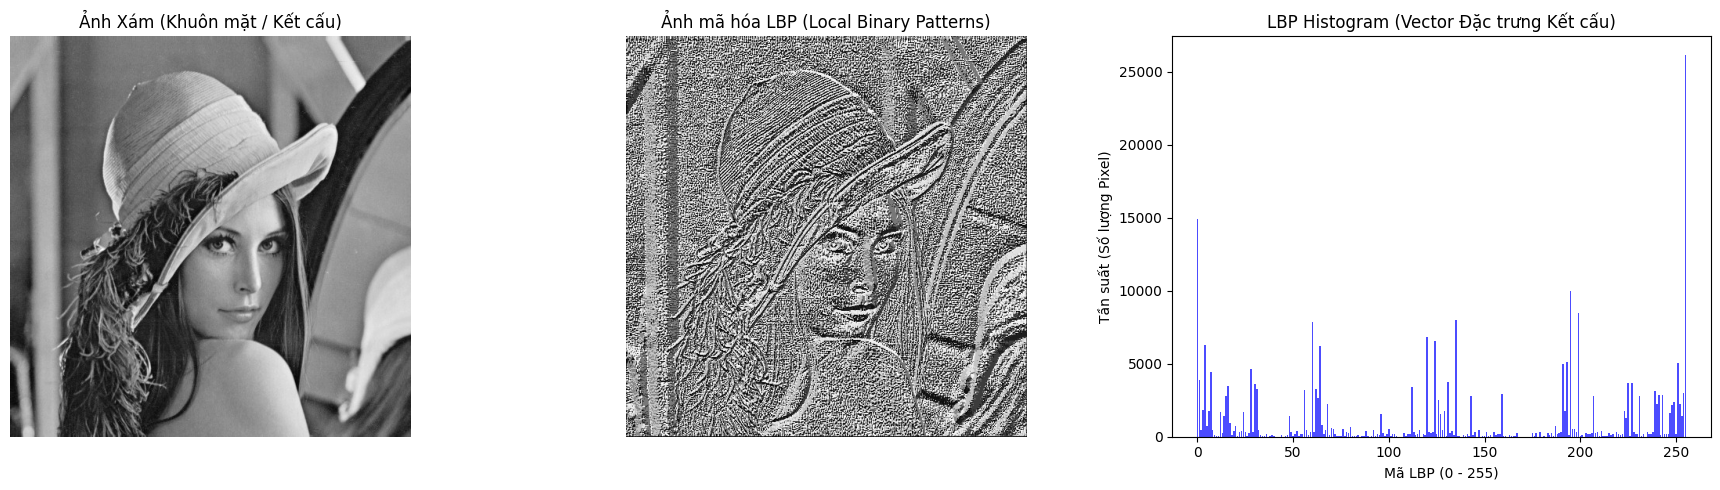

In [10]:
# Chuyển ảnh khuôn mặt sang ảnh xám
gray_face = cv2.cvtColor(img_face, cv2.COLOR_BGR2GRAY)

# Thiết lập các tham số cho thuật toán LBP
# Dùng cấu trúc 3x3 kinh điển: bán kính R=1, số điểm lân cận P=8
R = 1
P = 8 * R

# Trích xuất ảnh LBP (Chỉ định method='default' để tính LBP tiêu chuẩn)
lbp_image = feature.local_binary_pattern(gray_face, P, R, method="default")

# Chuyển đổi dữ liệu về dạng uint8 (0-255) để dễ dàng hiển thị và tính toán histogram
lbp_image = np.uint8(lbp_image)

# Tạo Histogram của ảnh LBP (Đại diện cho vector đặc trưng kết cấu)
# Số lượng bin là 256 tương ứng với 2^8 cấu trúc nhị phân có thể có
hist, _ = np.histogram(lbp_image.ravel(), bins=256, range=(0, 256))

# Trực quan hóa
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

# 1. Ảnh gốc xám
axs[0].imshow(gray_face, cmap='gray')
axs[0].set_title('Ảnh Xám (Khuôn mặt / Kết cấu)')
axs[0].axis('off')

# 2. Ảnh LBP (Trực quan hóa cấu trúc)
axs[1].imshow(lbp_image, cmap='gray')
axs[1].set_title('Ảnh mã hóa LBP (Local Binary Patterns)')
axs[1].axis('off')

# 3. Biểu đồ Histogram của LBP
axs[2].bar(np.arange(0, 256), hist, color='blue', alpha=0.7)
axs[2].set_title('LBP Histogram (Vector Đặc trưng Kết cấu)')
axs[2].set_xlabel('Mã LBP (0 - 255)')
axs[2].set_ylabel('Tần suất (Số lượng Pixel)')

plt.tight_layout()
plt.show()

*Gợi ý thảo luận cho sinh viên:* Hãy yêu cầu sinh viên thử thay đổi độ sáng (nhân thêm hoặc cộng thêm hằng số vào `gray_face`) và in lại LBP Histogram. Họ sẽ nhận thấy LBP Histogram gần như không đổi, chứng minh tính bất biến với độ sáng toàn cục của thuật toán này.

### Phần 2: So khớp Đặc trưng (Feature Matching) và Ghép ảnh Toàn cảnh

**Mục tiêu:** Hiểu cách thiết lập các cặp tương ứng (correspondences) giữa các ảnh. Thực hành hai phương pháp so khớp Brute-Force và FLANN, sử dụng kỹ thuật lọc Ratio Test để loại bỏ các điểm khớp sai. Cuối cùng, tính toán ma trận Homography để ghép hai bức ảnh thành một ảnh Panorama.

#### 2.1 Chuẩn bị dữ liệu và Trích xuất SIFT
Chúng ta sẽ cần hai bức ảnh chụp cùng một không gian nhưng ở góc độ hơi khác nhau (có phần chồng lấp) làm dữ liệu đầu vào.



In [11]:
# Tải 2 bức ảnh có phần chồng lấp để thực hành ghép ảnh (Panorama)
!wget -q -O left.jpg "https://raw.githubusercontent.com/opencv/opencv/master/samples/data/left01.jpg"
!wget -q -O right.jpg "https://raw.githubusercontent.com/opencv/opencv/master/samples/data/right01.jpg"

img_left = cv2.imread('left.jpg')
img_right = cv2.imread('right.jpg')

# Khởi tạo SIFT và trích xuất điểm đặc trưng + vector mô tả cho cả 2 ảnh
sift = cv2.SIFT_create()
kp1, des1 = sift.detectAndCompute(cv2.cvtColor(img_left, cv2.COLOR_BGR2GRAY), None)
kp2, des2 = sift.detectAndCompute(cv2.cvtColor(img_right, cv2.COLOR_BGR2GRAY), None)

print(f"Số điểm SIFT ảnh trái: {len(kp1)} | Ảnh phải: {len(kp2)}")

Số điểm SIFT ảnh trái: 1570 | Ảnh phải: 1323


#### 2.2 So khớp trực diện (Brute-Force) và Lọc Ratio Test
Bộ so khớp vét cạn (Brute-Force) hoạt động bằng cách lấy từng vector mô tả ở ảnh truy vấn (ảnh trái) và tính khoảng cách L2 với *tất cả* các vector trong ảnh cảnh (ảnh phải) để tìm ra láng giềng gần nhất.

Tuy nhiên, để loại bỏ các cặp khớp sai (False Matches) do nhiễu hoặc hoa văn lặp lại, ta không chỉ tìm 1 mà sẽ tìm 2 láng giềng gần nhất ($k=2$). Theo nguyên lý **Lowe's Ratio Test**, ta chỉ giữ lại cặp khớp nếu khoảng cách tới điểm gần nhất nhỏ hơn rõ rệt (ví dụ $0.75$ lần) so với điểm gần thứ hai.

Số lượng cặp khớp tốt (BFMatcher): 385


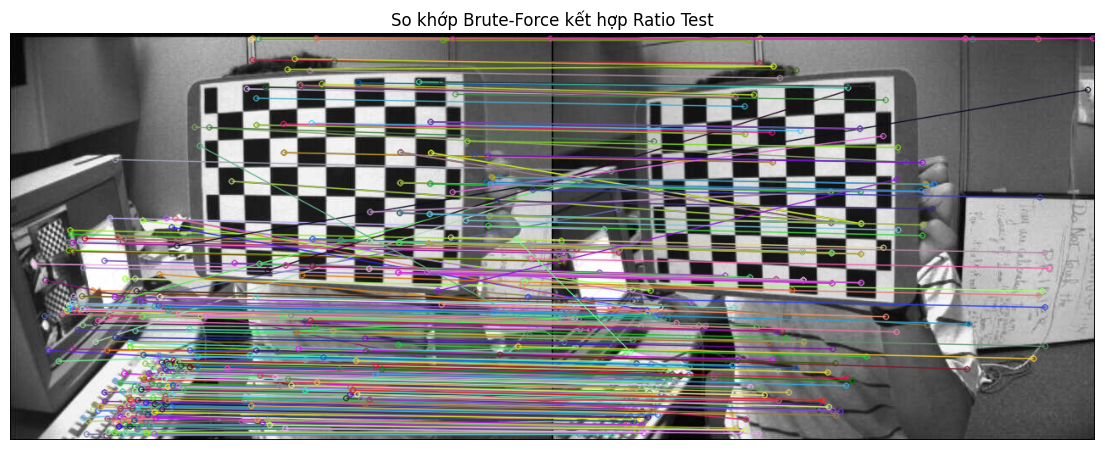

In [12]:
# Khởi tạo BFMatcher với khoảng cách L2 (dành cho SIFT/SURF)
bf = cv2.BFMatcher(cv2.NORM_L2)

# Sử dụng knnMatch để tìm 2 ứng viên gần nhất cho mỗi điểm
matches_bf = bf.knnMatch(des1, des2, k=2)

# Áp dụng Ratio Test lọc nhiễu
good_matches_bf = []
for m, n in matches_bf:
    # Nếu D1 < 0.75 * D2 thì điểm gần nhất thực sự vượt trội
    if m.distance < 0.75 * n.distance:
        good_matches_bf.append([m])

print(f"Số lượng cặp khớp tốt (BFMatcher): {len(good_matches_bf)}")

# Trực quan hóa kết quả bằng cv2.drawMatchesKnn
# Dùng cờ NOT_DRAW_SINGLE_POINTS để loại bỏ các điểm không có đường nối, giúp ảnh sạch hơn
matched_img_bf = cv2.drawMatchesKnn(img_left, kp1, img_right, kp2, good_matches_bf, None,
                                    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

imshow_cv('So khớp Brute-Force kết hợp Ratio Test', matched_img_bf, figsize=(14, 7))

#### 2.3 So khớp tốc độ cao với FLANN
Khi tập dữ liệu chứa hàng nghìn hoặc hàng triệu điểm đặc trưng, thuật toán Brute-Force sẽ trở thành "nút thắt cổ chai". Thay vào đó, ta sử dụng **FLANN** (Fast Library for Approximate Nearest Neighbors). Kỹ thuật này sử dụng cấu trúc cây k-d để tìm kiếm xấp xỉ, giúp tốc độ tăng lên gấp nhiều lần.

In [14]:
# Cấu hình tham số cho FLANN
FLANN_INDEX_KDTREE = 1
index_params = dict(algorithm = FLANN_INDEX_KDTREE, trees = 5) # Số lượng cây K-D
search_params = dict(checks = 50) # Số lần kiểm tra đệ quy (càng cao càng chính xác nhưng chậm)

# Khởi tạo bộ so khớp FLANN
flann = cv2.FlannBasedMatcher(index_params, search_params)
matches_flann = flann.knnMatch(des1, des2, k=2)

# Lọc Ratio Test cho FLANN
good_matches_flann = []
for m, n in matches_flann:
    if m.distance < 0.75 * n.distance:
        good_matches_flann.append(m) # Lưu dạng điểm đơn (không phải list) để chuẩn bị ghép ảnh

print(f"Số lượng cặp khớp tốt (FLANN): {len(good_matches_flann)}")

Số lượng cặp khớp tốt (FLANN): 392


#### 2.4 Mini-project: Xây dựng hệ thống ghép ảnh Panorama
Với các cặp điểm tương ứng (good matches) đã tìm được, chúng ta sẽ tính **ma trận Homography ($H$)** để xác định phép biến đổi phối cảnh, đưa ảnh trái về cùng hệ tọa độ với ảnh phải.

*Lưu ý:* Ta sẽ dùng thuật toán `cv2.RANSAC` để đánh giá và bỏ qua các cặp khớp ngoại lai (outliers) một lần nữa, đảm bảo đường ghép chuẩn xác.

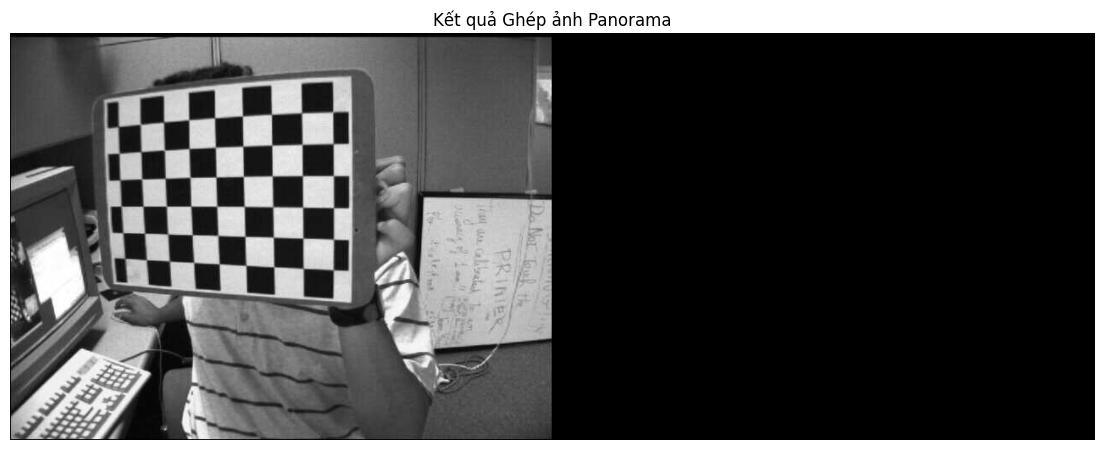

In [15]:
# Cần tối thiểu 4 điểm để tính Homography, ta yêu cầu ít nhất 10 điểm để an toàn
MIN_MATCH_COUNT = 10

if len(good_matches_flann) > MIN_MATCH_COUNT:
    # Lấy tọa độ (x, y) của các điểm khớp tốt từ 2 ảnh
    src_pts = np.float32([ kp1[m.queryIdx].pt for m in good_matches_flann ]).reshape(-1, 1, 2)
    dst_pts = np.float32([ kp2[m.trainIdx].pt for m in good_matches_flann ]).reshape(-1, 1, 2)

    # 1. Tính ma trận biến đổi phối cảnh Homography
    # Tham số 5.0 là ngưỡng lỗi tối đa (tính bằng pixel) để RANSAC chấp nhận 1 điểm là inlier
    M, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)

    # Lấy kích thước ảnh bên phải
    h, w, _ = img_right.shape

    # 2. Làm cong và ghép ảnh (Warping)
    # Mở rộng chiều ngang không gian đích để đủ sức chứa cả ảnh trái đã bị làm cong
    panorama = cv2.warpPerspective(img_left, M, (w * 2, h))

    # Đè ảnh bên phải lên vùng trống của không gian mới
    panorama[0:h, 0:w] = img_right

    imshow_cv('Kết quả Ghép ảnh Panorama', panorama, figsize=(14, 7))
else:
    print(f"Không đủ điểm khớp để tính Homography. Cần {MIN_MATCH_COUNT}, nhưng chỉ có {len(good_matches_flann)}")

*Gợi ý thảo luận cho sinh viên:* Tại ranh giới giao nhau giữa hai bức ảnh ghép, các em có thể thấy một đường gấp khúc (seam) khác biệt về độ sáng hoặc viền đen. Trong các bài toán nâng cao hơn, người ta sẽ phải tiếp tục thực hiện thêm bước *Pixel selection and weighting* hoặc *Feathering* (làm mờ khoảng cách) để có bức ảnh ghép mượt mà hoàn hảo.

### Phần 3: Phân loại ảnh cơ bản với thuật toán K-NN và Bag of Features (BoF)

**Mục tiêu:** Áp dụng quy trình phân lớp ảnh có giám sát thông qua 2 giai đoạn: Huấn luyện và Dự đoán. Do các thuật toán trích xuất đặc trưng cục bộ (như SIFT, SURF) trả về số lượng keypoint khác nhau cho mỗi ảnh, ta cần dùng kỹ thuật **Bag-of-Features (BoF)** để chuyển chúng về các vector histogram có kích thước cố định trước khi phân loại. Cuối cùng, ta sẽ sử dụng thuật toán **K-Hàng xóm gần nhất (K-NN)** để phân loại.

#### 3.1 Kỹ thuật Bag of Features (BoF) - Xây dựng "Từ điển thị giác"
Theo lý thuyết, BoF sẽ gom tất cả các vector mô tả (descriptors) trích xuất được từ toàn bộ tập ảnh huấn luyện, sau đó sử dụng thuật toán **K-Means Clustering** để nhóm chúng thành $K$ cụm.

Tâm của mỗi cụm được gọi là một **"từ vựng thị giác" (visual word)**, và tập hợp các tâm cụm này tạo thành một **Từ điển thị giác (Visual Dictionary / Codebook)**. Mỗi bức ảnh sau đó được lượng hóa và biểu diễn dưới dạng một vector Histogram đếm tần suất xuất hiện của các từ vựng này.


Tổng số descriptors trích xuất được: (2893, 128)


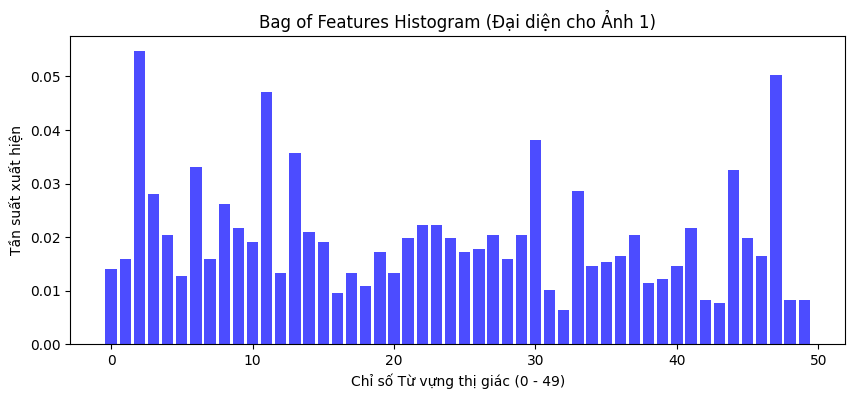

In [16]:
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Giả lập: Ta dùng lại des1 và des2 (từ ảnh left.jpg và right.jpg ở Phần 2)
# Trong thực tế, bạn sẽ vòng lặp để lấy descriptors của hàng ngàn ảnh trong tập Train

# 1. Gom tất cả descriptors của tập huấn luyện lại thành một ma trận lớn
# Các descriptor SIFT có kích thước 128 chiều
all_descriptors = np.vstack((des1, des2))
print(f"Tổng số descriptors trích xuất được: {all_descriptors.shape}")

# 2. Xây dựng "Từ điển thị giác" bằng K-Means
# Chọn K = 50 từ vựng thị giác (Số cụm)
num_clusters = 50
kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)

# Chạy K-Means để tìm tâm cụm (Bước này có thể tốn thời gian với dữ liệu lớn)
kmeans.fit(all_descriptors)

# kmeans.cluster_centers_ chính là Từ điển thị giác của chúng ta

# 3. Hàm biểu diễn một ảnh thành vector Histogram (K chiều)
def extract_bof_histogram(descriptor, kmeans_model, num_clusters):
    if descriptor is not None:
        # Lượng hóa: Tìm "từ vựng" (cụm) gần nhất cho mỗi descriptor trong ảnh
        words = kmeans_model.predict(descriptor)
        # Tạo biểu đồ tần suất (Histogram)
        hist, _ = np.histogram(words, bins=np.arange(num_clusters + 1), density=True)
    else:
        hist = np.zeros(num_clusters)
    return hist

# Chuyển đổi 2 ảnh ban đầu thành 2 vector đặc trưng BoF (50 chiều cố định)
hist1 = extract_bof_histogram(des1, kmeans, num_clusters)
hist2 = extract_bof_histogram(des2, kmeans, num_clusters)

# Trực quan hóa vector Histogram của Ảnh 1
plt.figure(figsize=(10, 4))
plt.bar(range(num_clusters), hist1, color='blue', alpha=0.7)
plt.title('Bag of Features Histogram (Đại diện cho Ảnh 1)')
plt.xlabel('Chỉ số Từ vựng thị giác (0 - 49)')
plt.ylabel('Tần suất xuất hiện')
plt.show()

#### 3.2 Huấn luyện mô hình phân loại K-NN (K-Nearest Neighbors)
K-NN là thuật toán **Học lười (Lazy learning)**, có nghĩa là trong giai đoạn "Học", nó không mất công xây dựng một mô hình toán học phức tạp mà chỉ đơn giản là lưu trữ lại toàn bộ tập dữ liệu huấn luyện. Khi có một ảnh mới cần dự đoán, nó sẽ tính khoảng cách (thường dùng khoảng cách Euclidean) tới tất cả các ảnh trong kho, chọn ra $K$ láng giềng gần nhất và phân loại dựa trên **cơ chế bỏ phiếu đa số**.

**Lưu ý cực kỳ quan trọng:** K-NN rất nhạy cảm với thang đo của đặc trưng. Chúng ta **bắt buộc phải chuẩn hóa dữ liệu (Feature Scaling)** về dải $0 - 1$ hoặc chuẩn hóa sao cho giá trị trung bình bằng 0 và độ lệch chuẩn bằng 1 để mọi đặc trưng đều đóng góp ngang nhau.

In [18]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Giả lập bộ dữ liệu BoF cho 100 ảnh để demo huấn luyện K-NN
# (Giả sử có 50 ảnh Chó - Nhãn 0, và 50 ảnh Mèo - Nhãn 1)
# Mỗi ảnh đã được biểu diễn bằng một vector BoF 50 chiều như hàm extract_bof_histogram bên trên
X_dummy = np.random.rand(100, num_clusters)
y_dummy = np.array([0]*50 + [1]*50)

# Chia tập dữ liệu thành Tập huấn luyện (Train 70%) và Tập kiểm tra (Test 30%)
X_train, X_test, y_train, y_test = train_test_split(X_dummy, y_dummy, test_size=0.3, random_state=42)

# 1. Chuẩn hóa dữ liệu (Feature Scaling)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test) # Dùng lại bộ thông số chuẩn hóa của Train cho Test

# 2. Khởi tạo và Huấn luyện mô hình K-NN
# Lựa chọn K = 5 láng giềng gần nhất và dùng khoảng cách Euclidean
knn = KNeighborsClassifier(n_neighbors=5, metric='euclidean')

# Hàm .fit() thực hiện việc lưu trữ dữ liệu vào bộ nhớ ("Học lười")
knn.fit(X_train_scaled, y_train)

# 3. Giai đoạn Dự đoán (Predict)
y_pred = knn.predict(X_test_scaled)

# Đánh giá độ chính xác (Accuracy)
accuracy = accuracy_score(y_test, y_pred)
print(f"Độ chính xác của mô hình K-NN trên tập kiểm tra: {accuracy * 100:.2f}%")

Độ chính xác của mô hình K-NN trên tập kiểm tra: 60.00%


**Thảo luận cho sinh viên:**
*   **Câu hỏi:** Điều gì xảy ra đối với biên quyết định (decision boundary) nếu chúng ta chọn siêu tham số $K$ quá nhỏ (ví dụ $K=1$) hoặc quá lớn?
*   **Gợi ý trả lời:** Hiệu năng của K-NN phụ thuộc rất lớn vào $K$.
    *   Nếu chọn $K$ **quá nhỏ**, mô hình trở nên rất nhạy cảm với nhiễu, dẫn đến hiện tượng **Quá khớp (Overfitting)** với các đường biên phân loại cực kỳ phức tạp và răng cưa.
    *   Nếu chọn $K$ **quá lớn**, ranh giới giữa các lớp sẽ bị làm mờ, dẫn đến hiện tượng **Dưới khớp (Underfitting)** do mô hình bị "mượt hóa" quá mức.
    *   Trong thực tế, ta thường dùng kỹ thuật **Kiểm chứng chéo (Cross-validation)** để rà soát và tìm ra giá trị $K$ tối ưu nhất cho tập dữ liệu đang dùng.

# BÀI TẬP

### Chủ đề 1: Đặc trưng Vùng (HOG) và Đặc trưng Kết cấu (LBP)

**Bài tập 1: Phân tích cấu trúc lưới của đặc trưng HOG**
*   **Yêu cầu:** Khởi tạo bộ mô tả HOG mặc định, trích xuất đặc trưng từ một bức ảnh chứa người và in ra kích thước của vector kết quả.
*   **Hướng dẫn:**
    *   Khái niệm: HOG chia ảnh thành các ô (cells, ví dụ $8 \times 8$) và tính biểu đồ gradient 9 hướng, sau đó nhóm các ô thành các khối (blocks) chồng lấp lên nhau để chuẩn hóa.
    *   Dùng `cv2.HOGDescriptor()`. Truyền một ảnh kích thước chuẩn (ví dụ $64 \times 128$) vào hàm `.compute()`. In `.shape` của vector đầu ra và dùng toán học để giải thích con số này (ví dụ: 3.780 chiều cho cấu trúc nhận diện người mặc định).

**Bài tập 2: Phát hiện người đi bộ với HOG và Linear SVM**
*   **Yêu cầu:** Áp dụng bộ phân loại đã được huấn luyện sẵn của OpenCV để vẽ Bounding Box bao quanh người đi bộ trong một bức ảnh đường phố.
*   **Hướng dẫn:**
    *   Dalal và Triggs đã chứng minh HOG kết hợp với Linear SVM (Máy vector hỗ trợ) là tiêu chuẩn vàng để phát hiện người nhờ khả năng bắt được "đường bao" cơ thể ổn định.
    *   Sử dụng hàm `hog.setSVMDetector(cv2.HOGDescriptor_getDefaultPeopleDetector())`.
    *   Sử dụng hàm `hog.detectMultiScale()` để quét cửa sổ trượt (sliding window) trên toàn bộ ảnh và thu về tọa độ các khung hình chữ nhật. Dùng `cv2.rectangle` để trực quan hóa.

**Bài tập 3: Khảo sát tính bất biến chiếu sáng của LBP (Local Binary Patterns)**
*   **Yêu cầu:** Trích xuất và so sánh vector đặc trưng LBP của cùng một bức ảnh ở hai độ sáng khác nhau.
*   **Hướng dẫn:**
    *   Thuật toán LBP xét cửa sổ $3 \times 3$, so sánh cường độ 8 pixel lân cận với pixel trung tâm để tạo mã nhị phân 8-bit. LBP cực kỳ hiệu quả để mô tả kết cấu bề mặt (ví dụ: da mặt) và bất biến với sự thay đổi độ sáng toàn cục.
    *   Dùng `skimage.feature.local_binary_pattern`.
    *   Tạo ra một bản sao của ảnh đã được cộng thêm một hằng số độ sáng. Vẽ biểu đồ Histogram (với 256 bin) cho cả hai ảnh LBP và nhận xét sự tương đồng của hai biểu đồ.

### Chủ đề 2: So khớp Đặc trưng (Feature Matching) và Lọc nhiễu

**Bài tập 4: So khớp vét cạn với Brute-Force Matcher**
*   **Yêu cầu:** Trích xuất đặc trưng SIFT/SURF từ 2 bức ảnh (ảnh truy vấn và ảnh cảnh) và tiến hành so khớp trực diện.
*   **Hướng dẫn:**
    *   Brute-Force tính toán khoảng cách từ mỗi vector trong ảnh truy vấn đến *tất cả* vector trong ảnh cảnh.
    *   Sử dụng `cv2.BFMatcher(cv2.NORM_L2)` (khoảng cách Euclidean dùng cho SIFT/SURF).
    *   Dùng hàm `bf.match()` để tìm cặp điểm tương đồng nhất, sau đó trực quan hóa kết quả bằng `cv2.drawMatches`. Quan sát hiện tượng các đường nối chằng chịt và nhiều cặp khớp sai (false matches).

**Bài tập 5: Tối ưu tốc độ với thư viện FLANN**
*   **Yêu cầu:** Thực hiện lại tác vụ của Bài tập 4 nhưng thay bằng FLANN Matcher. Đo lường và so sánh thời gian thực thi.
*   **Hướng dẫn:**
    *   FLANN (Fast Library for Approximate Nearest Neighbors) sử dụng cấu trúc cây k-d để tìm kiếm xấp xỉ, giúp tăng tốc độ lên gấp nhiều lần so với BF Matcher khi dữ liệu lớn.
    *   Sử dụng lớp `cv2.FlannBasedMatcher()`. Dùng thư viện `time` để bọc quanh đoạn code `.match()` của cả BF và FLANN, in kết quả ra màn hình để chứng minh FLANN nhanh hơn.

**Bài tập 6: Loại bỏ khớp sai bằng Kỹ thuật Kiểm tra tỷ lệ (Lowe's Ratio Test)**
*   **Yêu cầu:** Khắc phục tình trạng "rác" đường nối ở Bài 4 bằng bộ lọc Ratio Test.
*   **Hướng dẫn:**
    *   Vấn đề: Do hoa văn lặp lại, một điểm có thể giống với nhiều điểm, cần màng lọc giữ lại các cặp khớp thực sự tin cậy.
    *   Thay vì `.match()`, hãy dùng `bf.knnMatch(des1, des2, k=2)` để tìm 2 hàng xóm gần nhất cho mỗi điểm.
    *   Viết vòng lặp kiểm tra: Chỉ giữ lại cặp điểm nếu khoảng cách tới điểm gần nhất ($D_1$) nhỏ hơn một tỷ lệ (ví dụ $0.75$) nhân với khoảng cách tới điểm gần thứ hai ($D_2$). Dùng `cv2.drawMatchesKnn` để hiển thị các đường nối hội tụ chính xác vào vật thể.

### Chủ đề 3: Ứng dụng Ghép ảnh Toàn cảnh (Panorama)

**Bài tập 7: Tính Ma trận Homography và Warping**
*   **Yêu cầu:** Từ danh sách các cặp khớp tốt (good matches) ở Bài 6, tiến hành ghép hai bức ảnh có phần chồng lấp thành một ảnh Panorama liền mạch.
*   **Hướng dẫn:**
    *   Tách mảng tọa độ $(x, y)$ của các điểm trên ảnh 1 và ảnh 2.
    *   Sử dụng hàm `cv2.findHomography()` với tham số `cv2.RANSAC` để tính ma trận biến đổi phối cảnh và loại bỏ các điểm ngoại lai (outliers).
    *   Dùng hàm `cv2.warpPerspective()` để biến dạng (warp) bức ảnh thứ nhất theo hệ tọa độ của bức ảnh thứ hai, sau đó đè bức ảnh thứ hai lên vùng trống để hoàn thiện.

### Chủ đề 4: Mô hình "Túi đặc trưng" (Bag of Features - BoF)

**Bài tập 8: Xây dựng Từ điển Thị giác (Visual Dictionary) bằng K-Means**
*   **Yêu cầu:** Lấy tập hợp hàng nghìn vector SIFT từ các ảnh huấn luyện và chuyển chúng thành các vector có số chiều cố định đại diện cho cả bức ảnh.
*   **Hướng dẫn:**
    *   Lý do: Bộ phân lớp học máy (như K-NN) yêu cầu đầu vào là vector cố định kích thước, trong khi SIFT sinh ra số lượng điểm khác nhau cho mỗi ảnh.
    *   Sử dụng `sklearn.cluster.KMeans` gom cụm tất cả các vector đặc trưng thành $K$ cụm. Tâm của mỗi cụm chính là một "từ vựng thị giác" (visual word) tạo nên Từ điển thị giác (Codebook).
    *   Lượng hóa một ảnh mới: Thay thế mỗi descriptor cục bộ bằng "từ vựng" gần nhất, đếm tần suất xuất hiện và trả về biểu đồ Histogram $K$ chiều.

### Chủ đề 5: Phân loại ảnh với K-NN (K-Nearest Neighbors)

**Bài tập 9: Tầm quan trọng của Chuẩn hóa đặc trưng (Feature Scaling)**
*   **Yêu cầu:** Chạy thuật toán K-NN trên dữ liệu BoF (từ Bài 8) với 2 trường hợp: chưa chuẩn hóa và đã chuẩn hóa.
*   **Hướng dẫn:**
    *   K-NN là thuật toán "học lười" dựa vào việc tính khoảng cách (Euclidean) để tìm các láng giềng gần nhất. Nếu không chuẩn hóa, các đặc trưng có giá trị số học lớn sẽ áp đảo hoàn toàn các đặc trưng nhỏ.
    *   Sử dụng lớp `KNeighborsClassifier` của `sklearn` để thực hiện lệnh `.fit()` và `.predict()`.
    *   Trước khi fit, hãy dùng `StandardScaler` để đưa các vector đặc trưng về phân bố có trung bình bằng 0, độ lệch chuẩn bằng 1. Ghi nhận sự khác biệt về độ chính xác (Accuracy).

**Bài tập 10: Tránh Quá khớp (Overfitting) bằng tinh chỉnh siêu tham số $K$**
*   **Yêu cầu:** Đánh giá hiệu năng của mô hình K-NN khi thay đổi số lượng láng giềng ($K$).
*   **Hướng dẫn:**
    *   Hiệu năng K-NN cực kỳ nhạy cảm với $K$. $K$ quá nhỏ (như $K=1$) khiến mô hình nhạy cảm với nhiễu gây Quá khớp (Overfitting); $K$ quá lớn sẽ làm mờ ranh giới các lớp gây Dưới khớp (Underfitting).
    *   Viết vòng lặp huấn luyện K-NN với các giá trị $K \in \{1, 3, 5, 15, 50\}$.
    *   Tính điểm chính xác trên cả tập Train và tập Test. Vẽ biểu đồ đường thể hiện sự thay đổi độ chính xác theo $K$. Tìm ra giá trị $K$ tối ưu nhất (thường thông qua cơ chế Kiểm chứng chéo - Cross-validation).